In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from py_eddy_tracker import data
from py_eddy_tracker.observations.tracking import TrackEddiesObservations

The data is a **flat observation table** — one row per eddy detection, not a gridded time series:

- **`track`** — Eddy ID (groups observations into trajectories, 0–12,223)
- **`time`** — Days since 1950-01-01 (spans 1993-01-01 to 2019-05-13)
- **`latitude` / `longitude`** — Eddy center position
- **`amplitude`** — Height anomaly (m)
- **`speed_radius`** — Eddy radius
- **`speed_average`** — Average rotational speed
- **`observation_number`** — Sequence index within a track

**473,554 total observations** across **12,224 unique anticyclonic eddies**. Track lengths range from 10 to 1,183 days (median 21 days). Rows are sorted by track ID, then by time within each track.

In [6]:
import zarr
g = zarr.open_group('data/eddies_med_adt_allsat_dt2018/Anticyclonic.zarr', mode='r')
list(g.array_keys())

['amplitude',
 'latitude',
 'longitude',
 'observation_flag',
 'observation_number',
 'speed_average',
 'speed_contour_latitude',
 'speed_contour_longitude',
 'speed_contour_shape_error',
 'speed_radius',
 'time',
 'track']

In [7]:
a = TrackEddiesObservations.load_file('data/eddies_med_adt_allsat_dt2018/Anticyclonic.zarr')
c = TrackEddiesObservations.load_file('data/eddies_med_adt_allsat_dt2018/Cyclonic.zarr')

File was created with py-eddy-tracker version 'None' but software version is '0.0'
File was created with py-eddy-tracker version 'None' but software version is '0.0'


`.position_filter()` applies 2 filters to both longitude and latitude:
1. Median filter removes outliers by taking a window of 3 points and replaces each position with the median of its neighbors
2. LOESS filter smooths the trajectory by taking a window of 5 points on each side (11 total) and uses local weighted polynomial regression

In [8]:
a.position_filter(median_half_window=1, loess_half_window=5)
c.position_filter(median_half_window=1, loess_half_window=5)

Use colors to indicate time step

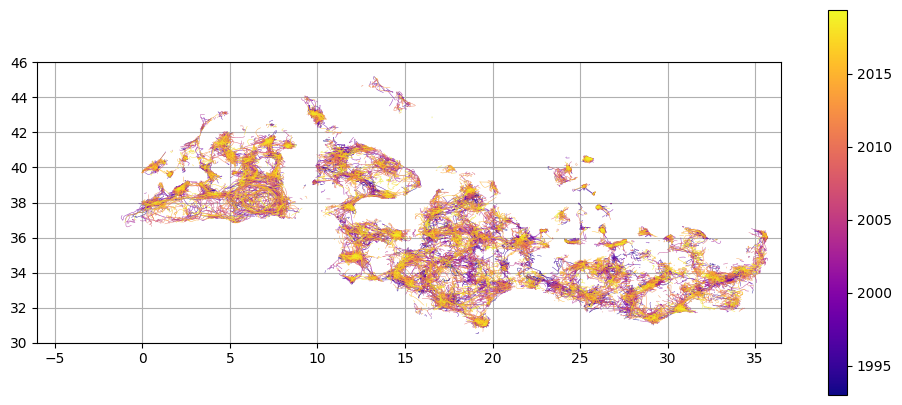

In [9]:
import matplotlib.dates as dates
from datetime import datetime

# Build plot for specific region
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_aspect('equal')
ax.set_xlim(-6, 36.5)
ax.set_ylim(30, 46)

# Normalize time to [0, 1] for colormap
# Initially in days since 1950
epoch_offset = dates.date2num(datetime(1950, 1, 1))
mpl_times = a.time + epoch_offset # use instead of a.time
t_norm = Normalize(vmin=np.min(mpl_times), vmax=np.max(mpl_times)) # pass in value to obtain normalized value

# Iterate over tracks
for i, _, _ in a.iter_on('track'):
    # i is a slice fulfilling a specific track, iterating through all tracks, if track is montonically increasing
    # otherwise it is an integer index array, used as fancy indexing in numpy
    lon = a.longitude[i]
    lat = a.latitude[i]
    t = mpl_times[i]

    # Build line segments
    points = np.column_stack((lon, lat)) # 2D array where 1D arrays are cols
    points = points.reshape(-1, 1, 2) # shape becomes (n_obs, 1, 2) where 2 is from lon/lat
    segments = np.concatenate([points[:-1], points[1:]], axis=1) # (n_obs, 2, 2); concatenates along 2nd axis and pairs each point with its successor (offset by 1)

    # Color each segment by time
    lc = LineCollection(segments, cmap='plasma', norm=t_norm, linewidth=0.3) #type:ignore
    lc.set_array(t[:-1]) # which values to map to color
    ax.add_collection(lc) #type:ignore

cbar = fig.colorbar(lc, ax=ax)
cbar.ax.yaxis.set_major_formatter(dates.DateFormatter('%Y'))
cbar.ax.yaxis.set_major_locator(dates.YearLocator(5))
ax.grid()
plt.show()